In [27]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

# Lecture 4 (Makemore pt 3): Notes on MLP internals: Activations, Gradients, BatchNorm

In [28]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)


In [29]:
# Built dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set 10%
Xte, Yte = build_dataset(words[n2:]) # test set 10%


In [31]:
# Construct and Initialize MLP
n_embd = 10 # the dimensionality of the character embedding vectors (latent space dimension I believe)
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # total number of parameters in model
for p in parameters:
    p.requires_grad = True

11897


In [32]:
# Gradient Descent
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):
    
    # minibatch construction (for computational speed)
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) # samples 32 indexes from dataset
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the chars into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer (log counts)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track states
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/ 200000 : 27.8817
  10000/ 200000 : 2.8138
  20000/ 200000 : 2.5218
  30000/ 200000 : 2.7874
  40000/ 200000 : 2.0334
  50000/ 200000 : 2.6237
  60000/ 200000 : 2.3289
  70000/ 200000 : 2.0826
  80000/ 200000 : 2.2784
  90000/ 200000 : 2.2252
 100000/ 200000 : 2.0428
 110000/ 200000 : 2.3121
 120000/ 200000 : 2.0570
 130000/ 200000 : 2.4546
 140000/ 200000 : 2.2233
 150000/ 200000 : 2.1551
 160000/ 200000 : 2.0597
 170000/ 200000 : 1.7981
 180000/ 200000 : 2.0194
 190000/ 200000 : 1.7459


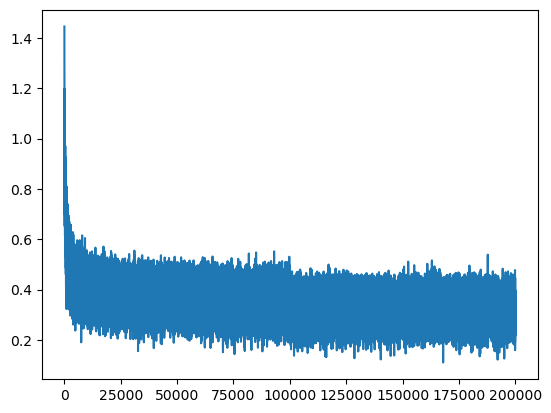

In [33]:
plt.plot(lossi)

In [40]:
@torch.no_grad() # this decorator disables gradient tracking (just for efficiency)
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), # why is this named val instead of dev?
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.1267659664154053
val 2.1697638034820557


In [38]:
# Sample from the Model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with ...
    while True:
        emb = C[torch.tensor([context])] # embed the current context
        h = torch.tanh(emb.view(1,-1) @ W1 + b1) # project embedding into the hidden layer (latent space)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) # get prob distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample index of next char from prob distribution
        context = context[1:] + [ix] # shift context window
        if ix == 0:
            break
        out.append(ix)
        

    print(''.join(itos[i] for i in out))

carlah
amorie
khirmin
rey
cassanden
jazhubedah
sart
kaeli
nellara
chaiir
kaleigh
ham
jore
quint
salin
alianni
wazthoniearyxi
jace
pirran
eddeci
